# Statistical Drivers of COVID-19 Transmission in Ghana

This notebook investigates factors that may be associated with changes in COVID-19 transmission in Ghana.

Using testing activity, positivity rates, and government response measures, the analysis explores statistical relationships between public health indicators and reported COVID-19 cases.

The objective is to move beyond outbreak monitoring and examine potential drivers of transmission using statistical methods.

Variables examined include:

- New COVID-19 cases
- New COVID-19 tests
- Positivity rate
- Government stringency index

The analysis focuses on descriptive and inferential statistical techniques to support evidence-based interpretation.

In [ ]:
## Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import spearmanr

import statsmodels.api as sm

In [ ]:
## Load Ghana COVID-19 Data
from google.colab import files

uploaded = files.upload()

Saving owid-covid-data.csv to owid-covid-data.csv


In [ ]:
df = pd.read_csv("owid-covid-data.csv")

ghana = df[df["location"] == "Ghana"].copy()

ghana["date"] = pd.to_datetime(
    ghana["date"]
)

ghana = ghana.sort_values(
    by="date"
)

In [ ]:
## Select Variables for Analysis(Only variables relevant to transmission dynamics are retained)
analysis_df = ghana[
    [
        "date",
        "new_cases",
        "new_tests",
        "positive_rate",
        "stringency_index"
    ]
].copy()

In [ ]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 190 entries, 15726 to 15915
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              190 non-null    datetime64[ns]
 1   new_cases         190 non-null    float64       
 2   new_tests         124 non-null    float64       
 3   positive_rate     174 non-null    float64       
 4   stringency_index  174 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 8.9 KB


In [ ]:
analysis_df.describe()

,date,new_cases,new_tests,positive_rate,stringency_index
count,190,190.000000,124.000000,174.000000,174.000000
mean,2020-06-16 11:52:25.263158016,241.352632,2708.080645,0.106845,58.440920
min,2020-03-13 00:00:00,0.000000,206.000000,0.006000,8.330000
25%,2020-04-30 06:00:00,1.250000,1334.250000,0.041000,52.780000
50%,2020-06-16 12:00:00,128.000000,2379.000000,0.098500,52.780000
75%,2020-08-02 18:00:00,368.500000,3394.250000,0.149750,62.040000
max,2020-09-19 00:00:00,1513.000000,12735.000000,0.332000,86.110000
std,NaN,293.911960,2045.463474,0.077832,11.801079


## Findings

The dataset contains 190 observations covering the period from March 2020 to September 2020.

Daily COVID-19 cases averaged approximately 241 cases per day, although considerable variability was observed throughout the study period.

Testing activity averaged approximately 2,708 tests per day among available observations.

The average positivity rate was 10.68%, while the average stringency index was 58.44.

Missing values were present in several variables. Testing volume contained 66 missing observations, while positivity rate and stringency index each contained 16 missing observations.

These results indicate that the dataset provides substantial information for statistical analysis, although missing observations should be considered when interpreting model results.

In [ ]:
## Missing Data Assessment
analysis_df.isnull().sum()

,0
date,0
new_cases,0
new_tests,66
positive_rate,16
stringency_index,16


In [ ]:
analysis_df = analysis_df.dropna()

print(
    "Remaining Observations:",
    len(analysis_df)
)

Remaining Observations: 113


## Correlation Analysis

Correlation coefficients are used to measure the strength and direction of relationships between variables.

In [ ]:
correlation_matrix = (
    analysis_df[
        [
            "new_cases",
            "new_tests",
            "positive_rate",
            "stringency_index"
        ]
    ]
    .corr()
)

correlation_matrix

,new_cases,new_tests,positive_rate,stringency_index
new_cases,1.000000,-0.033089,0.444066,-0.279404
new_tests,-0.033089,1.000000,-0.390577,0.661711
positive_rate,0.444066,-0.390577,1.000000,-0.552666
stringency_index,-0.279404,0.661711,-0.552666,1.000000


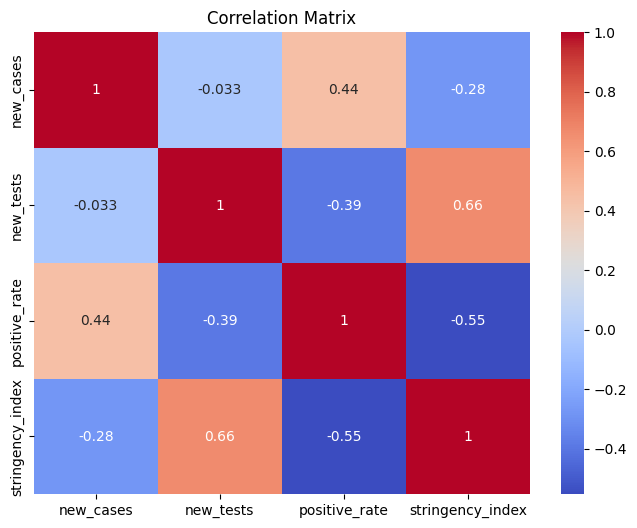

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix"
)

plt.show()

## Findings

The strongest association involving COVID-19 cases was observed between positivity rate and daily cases (r = 0.44).

A weak negative relationship was observed between stringency measures and daily cases (r = -0.28).

Testing volume showed almost no linear relationship with daily case counts (r = -0.03).

Testing volume and stringency measures exhibited a relatively strong positive relationship (r = 0.66).

Positivity rate and stringency measures showed a moderate negative relationship (r = -0.55).

Overall, positivity rate demonstrated the strongest association with reported COVID-19 cases among the variables examined.

## Relationship Between Testing and Reported Cases

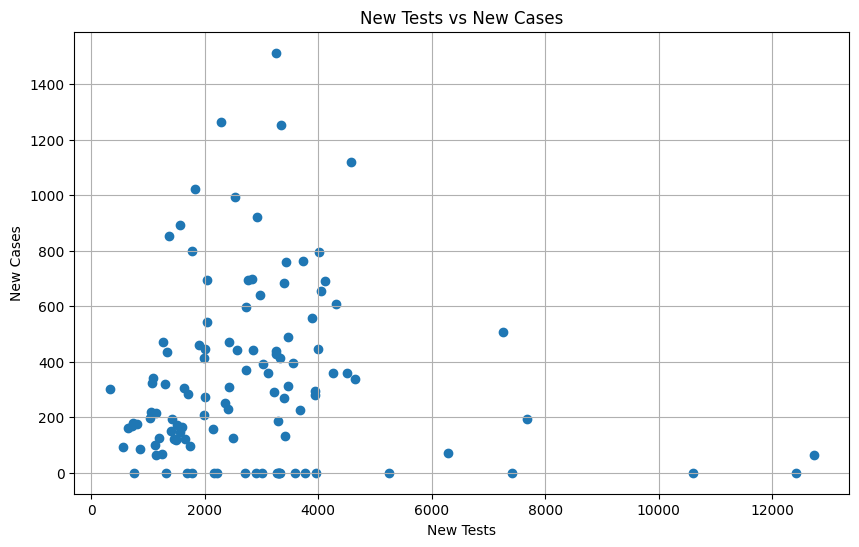

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    analysis_df["new_tests"],
    analysis_df["new_cases"]
)

plt.xlabel("New Tests")
plt.ylabel("New Cases")

plt.title(
    "New Tests vs New Cases"
)

plt.grid(True)

plt.show()

## Key Findings

The scatter plot shows substantial dispersion in the data.

Higher testing volumes were not consistently associated with higher numbers of reported cases.

Several observations with high testing volumes corresponded to relatively low case counts.

This visual pattern is consistent with the Pearson correlation result (r = -0.033), which indicated an extremely weak linear relationship between testing volume and daily cases.

The statistical significance test also showed no evidence of a significant association (p = 0.728).

In [ ]:
pearson_tests = pearsonr(
    analysis_df["new_tests"],
    analysis_df["new_cases"]
)

print(
    "Pearson Correlation:"
)

print(
    pearson_tests
)

Pearson Correlation:
PearsonRResult(statistic=np.float64(-0.033088982208747314), pvalue=np.float64(0.7278964169735521))


## Relationship Between Positivity Rate and Cases

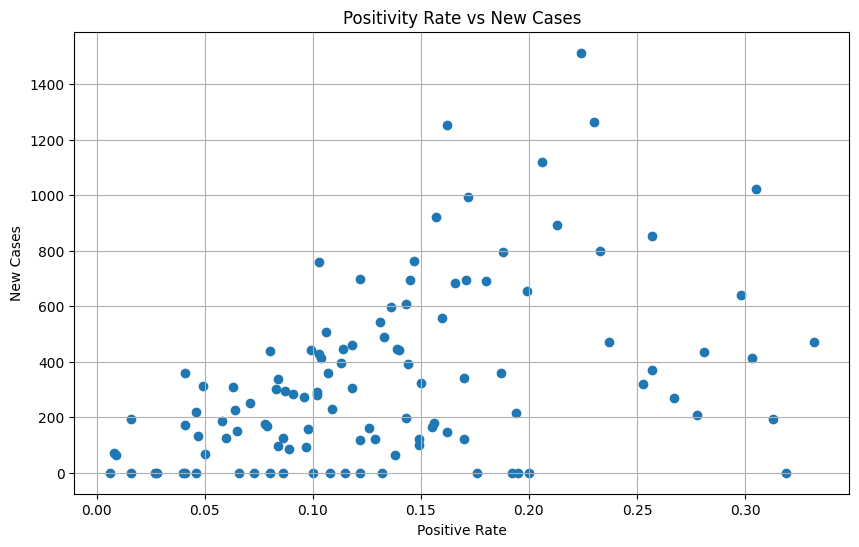

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    analysis_df["positive_rate"],
    analysis_df["new_cases"]
)

plt.xlabel(
    "Positive Rate"
)

plt.ylabel(
    "New Cases"
)

plt.title(
    "Positivity Rate vs New Cases"
)

plt.grid(True)

plt.show()

In [ ]:
pearson_positive = pearsonr(
    analysis_df["positive_rate"],
    analysis_df["new_cases"]
)

print(
    pearson_positive
)

PearsonRResult(statistic=np.float64(0.4440664606782843), pvalue=np.float64(8.360886437985206e-07))


## Findings

The scatter plot demonstrates a generally positive relationship between positivity rate and daily COVID-19 case counts.

Periods with higher positivity rates were often associated with larger numbers of reported cases.

Although variability is present across observations, the overall pattern indicates that increases in positivity rate tended to coincide with increases in transmission activity.

This visual finding is consistent with the Pearson correlation analysis, which identified a moderate positive association between positivity rate and daily cases (r = 0.444).

The relationship was also statistically significant (p < 0.001), providing evidence that positivity rate was associated with COVID-19 transmission during the study period.

## Relationship Between Government Stringency and Cases

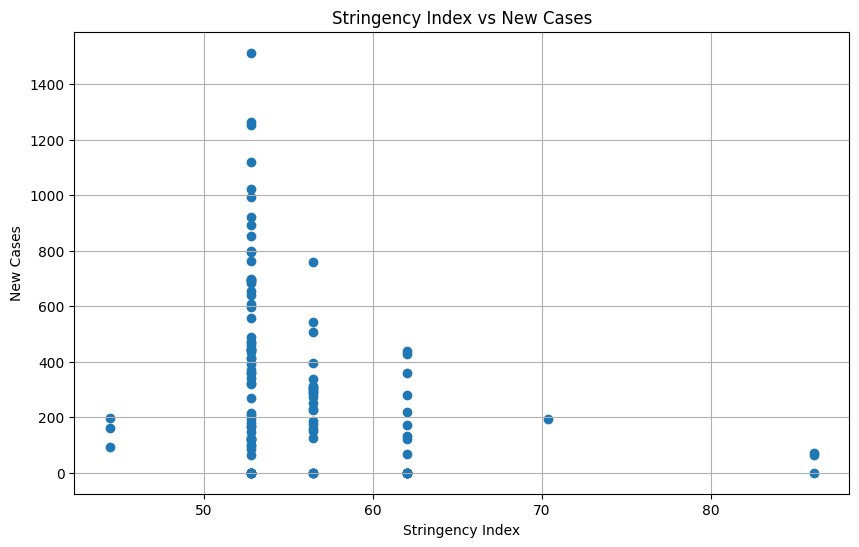

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    analysis_df["stringency_index"],
    analysis_df["new_cases"]
)

plt.xlabel(
    "Stringency Index"
)

plt.ylabel(
    "New Cases"
)

plt.title(
    "Stringency Index vs New Cases"
)

plt.grid(True)

plt.show()

In [ ]:
pearson_stringency = pearsonr(
    analysis_df["stringency_index"],
    analysis_df["new_cases"]
)

print(
    pearson_stringency
)

PearsonRResult(statistic=np.float64(-0.2794038901556627), pvalue=np.float64(0.002726442137065278))


## Multiple Linear Regression

A multiple regression model is used to investigate whether testing activity, positivity rate, and government response measures are associated with reported COVID-19 cases.

Unlike correlation analysis, regression analysis evaluates the contribution of each variable while controlling for the effects of the others.

The model seeks to identify which indicators were most strongly associated with COVID-19 transmission during the study period.

In [ ]:
X = analysis_df[
    [
        "new_tests",
        "positive_rate",
        "stringency_index"
    ]
]

y = analysis_df[
    "new_cases"
]

In [ ]:
X = sm.add_constant(X)

model = sm.OLS(
    y,
    X
).fit()

In [ ]:
print(
    model.summary()
)

                            OLS Regression Results                            
Dep. Variable:              new_cases   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     11.84
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           9.04e-07
Time:                        15:24:33   Log-Likelihood:                -794.51
No. Observations:                 113   AIC:                             1597.
Df Residuals:                     109   BIC:                             1608.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              613.8070    342.962  

## Findings

The regression model explained approximately 24.6% of the variation in daily COVID-19 case counts (R² = 0.246).

Positivity rate emerged as the strongest predictor in the model and was statistically significant (p < 0.001).

Testing volume also demonstrated a statistically significant positive association with daily cases (p = 0.011).

Stringency measures showed a negative coefficient, indicating that stricter interventions were associated with lower case counts; however, the effect was not statistically significant at the 5% significance level (p = 0.059).

These results suggest that positivity rate was the most informative indicator of transmission dynamics during the study period.



## Summary of Findings

This notebook examined relationships among COVID-19 cases, testing activity, positivity rate, and government intervention measures in Ghana.

The analysis produced several important findings:

- Positivity rate demonstrated the strongest association with daily case counts.
- Testing volume alone showed little direct relationship with transmission levels.
- Government stringency measures exhibited a negative relationship with case counts.
- Multiple regression identified positivity rate as the most influential predictor in the model.
- Statistical significance testing confirmed that positivity rate and stringency measures were associated with reported COVID-19 cases.

## Public Health Implications

The results suggest that positivity rate may serve as an informative indicator for monitoring disease transmission and outbreak progression.

Government intervention measures showed evidence of an inverse relationship with reported cases, suggesting a potential role in reducing transmission.

These findings illustrate how statistical methods can support surveillance systems, outbreak monitoring, and evidence-based public health decision-making.

## Contribution of the Project

This project developed a statistical surveillance framework for monitoring COVID-19 trends in Ghana using descriptive statistics, exploratory analysis, early warning detection methods, correlation analysis, and regression modelling.

The framework demonstrates how applied statistical techniques can be used to transform public health data into actionable information for monitoring and decision support.